# Park Proximity in Hamburg

## Objective
Compare the share of each district's area located more than
500 metres from mapped parks.

## Data and method
Park data come from Hamburg's Digitaler Grünplan / Kataster
der öffentlichen Grünanlagen. The analysis uses 951 features
classified as Parkanlagen.

In QGIS, 500 m straight-line buffers were created around the
park geometries. Areas outside these buffers were summarised
by district.

This notebook reads the QGIS results, compares the seven
districts, checks the consistency of stored areas and
percentages, and exports a ranked chart.

Projected coordinate system: EPSG:25832 — ETRS89 / UTM zone 32N.


In [1]:
from pathlib import Path
import sys

# Find the project folder from the notebook's working directory.
current = Path.cwd().resolve()
ROOT = next(
    (p for p in [current, *current.parents]
     if (p / "data_processed").is_dir()
     and (p / "notebooks").is_dir()),
    None
)

if ROOT is None:
    raise FileNotFoundError(
        f"Project folder not found. Current folder: {current}"
    )

DATA = ROOT / "data_processed"
OUTPUTS = ROOT / "outputs"
GPKG = DATA / "districts_access_summary.gpkg"

print("Python:", sys.executable)
print("Project:", ROOT)
print("Data file found:", GPKG.is_file())


Python: c:\Users\PC\Documents\hamburg-green-space\.venv\Scripts\python.exe
Project: C:\Users\PC\Documents\hamburg-green-space
Data file found: True


In [2]:
%pip install geopandas matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

districts = gpd.read_file(
    GPKG,
    layer="districts_access_summary"
)

print("Number of districts:", len(districts))
print("Coordinate reference system:", districts.crs)

columns = [
    "bezirk_name",
    "district_km2",
    "outside_km2",
    "outside_pct"
]

display(
    districts[columns]
    .sort_values("outside_pct", ascending=False)
    .round(2)
)


Number of districts: 7
Coordinate reference system: EPSG:25832


,bezirk_name,district_km2,outside_km2,outside_pct
6,Harburg,125.02,103.47,82.76
5,Bergedorf,154.62,122.05,78.94
0,Hamburg-Mitte,142.17,77.19,54.30
4,Wandsbek,147.43,73.44,49.81
2,Eimsbüttel,49.77,17.86,35.89
1,Altona,77.85,19.64,25.23
3,Hamburg-Nord,57.73,10.54,18.27


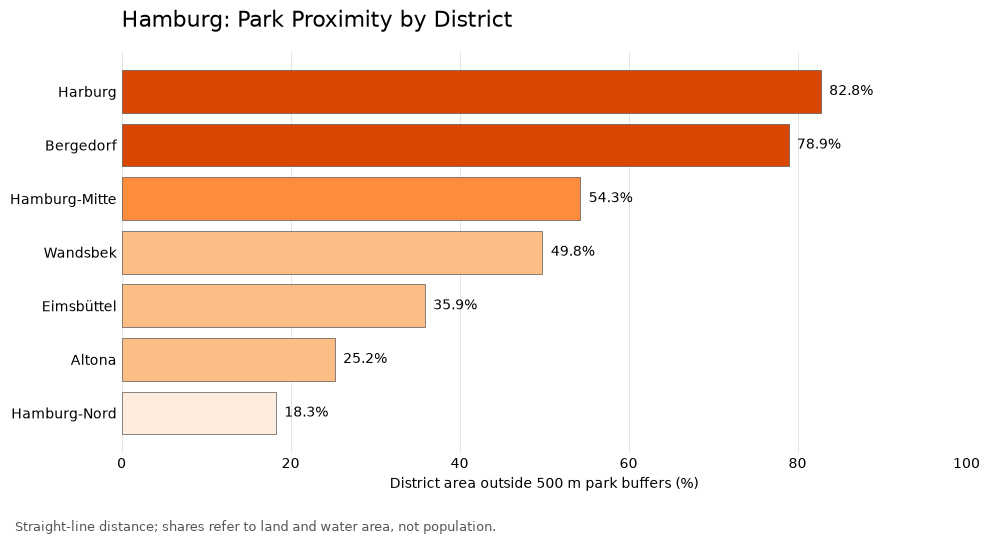

Chart saved as PNG and PDF in the outputs folder.


In [4]:
# Sort districts from highest to lowest percentage.
ranked = districts.sort_values("outside_pct", ascending=False)

# Use the same colour classes as the QGIS map.
def bar_colour(value):
    if value <= 25:
        return "#FEEDDE"
    if value <= 50:
        return "#FDBE85"
    if value <= 75:
        return "#FD8D3C"
    return "#D94701"

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    ranked["bezirk_name"],
    ranked["outside_pct"],
    color=[bar_colour(v) for v in ranked["outside_pct"]],
    edgecolor="#555555",
    linewidth=0.5
)

ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("District area outside 500 m park buffers (%)")
ax.set_title(
    "Hamburg: Park Proximity by District",
    loc="left",
    fontsize=16,
    pad=18
)

ax.bar_label(bars, fmt="%.1f%%", padding=6, fontsize=10)
ax.set_axisbelow(True)
ax.grid(axis="x", color="#E5E5E5", linewidth=0.7)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.02, 0.025,
    "Straight-line distance; shares refer to land and water area, not population.",
    fontsize=9,
    color="#555555"
)

fig.tight_layout(rect=[0, 0.07, 1, 1])

OUTPUTS.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUTS / "district_park_proximity_500m.png",
            dpi=300, bbox_inches="tight")
fig.savefig(OUTPUTS / "district_park_proximity_500m.pdf",
            bbox_inches="tight")

plt.show()
print("Chart saved as PNG and PDF in the outputs folder.")


In [5]:
import numpy as np

# Recalculate percentages from the stored areas.
calculated_pct = (
    districts["outside_km2"] / districts["district_km2"] * 100
)

checks = {
    "7 unique districts": (
        len(districts) == 7
        and districts["bezirk_name"].nunique() == 7
    ),
    "No missing area or percentage values": (
        districts[["district_km2", "outside_km2", "outside_pct"]]
        .notna().all().all()
    ),
    "Areas within valid limits": (
        (districts["district_km2"] > 0)
        & (districts["outside_km2"] >= 0)
        & (districts["outside_km2"] <= districts["district_km2"])
    ).all(),
    "Percentages match area calculations": np.allclose(
        districts["outside_pct"],
        calculated_pct,
        atol=0.01,
        rtol=0
    ),
    "Geometries valid": districts.geometry.is_valid.all(),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'CHECK'} — {name}")

# Citywide percentage: use total areas, not the average of district percentages.
city_pct = (
    districts["outside_km2"].sum()
    / districts["district_km2"].sum()
    * 100
)

print(f"\nCitywide area outside 500 m park buffers: {city_pct:.2f}%")


PASS — 7 unique districts
PASS — No missing area or percentage values
PASS — Areas within valid limits
PASS — Percentages match area calculations
PASS — Geometries valid

Citywide area outside 500 m park buffers: 56.22%


## Findings
- Across the combined district area, 56.22% lies outside
  the mapped 500 m park buffers.
- Harburg has the highest share (82.76%), followed by
  Bergedorf (78.94%).
- Hamburg-Nord has the lowest share (18.27%).
- The citywide percentage is calculated from summed areas,
  rather than an unweighted average of district percentages.

## Validation and limitations
All five internal checks passed: district uniqueness,
missing values, area limits, percentage consistency and
geometry validity.

These checks do not independently verify the original
buffer and overlay operations.

Distances are straight-line distances, not walking routes.
The analysis does not account for park entrances, physical
barriers, park quality or population distribution.

District area may include water, industrial and agricultural
land. A high percentage therefore does not, by itself,
demonstrate a need for new parks.

District-boundary attribution and dataset licence details
remain to be documented before publication.


In [6]:
for path in sorted(DATA.glob("*.gpkg")):
    print(path.name)

districts_access_summary.gpkg
districts_outside_500m.gpkg
hamburg_districts.gpkg
hamburg_parks.gpkg
hamburg_parks_fixed.gpkg
parks_buffer_300m.gpkg
parks_buffer_300m_clip.gpkg
parks_buffer_500m.gpkg
parks_buffer_500m_clip.gpkg


In [7]:
import sqlite3

buffer_files = {
    300: DATA / "parks_buffer_300m_clip.gpkg",
    500: DATA / "parks_buffer_500m_clip.gpkg",
}

for distance, path in buffer_files.items():
    with sqlite3.connect(path.as_uri() + "?mode=ro", uri=True) as connection:
        layers = connection.execute("""
            SELECT table_name, srs_id
            FROM gpkg_contents
            WHERE data_type = 'features'
        """).fetchall()

    print(f"{distance} m:", layers)

300 m: [('parks_buffer_300m_clip', 25832)]
500 m: [('parks_buffer_500m_clip', 25832)]


In [8]:
import pandas as pd
from shapely.ops import unary_union

# Use district geometries to calculate area in square metres.
district_geom = districts.to_crs(epsg=25832).copy()

if (
    district_geom.geometry.isna().any()
    or district_geom.geometry.is_empty.any()
    or not district_geom.geometry.is_valid.all()
):
    raise ValueError("District geometries need checking.")

comparison = district_geom[["bezirk_name"]].copy()
district_area = district_geom.geometry.area

for distance in (300, 500):
    buffers = gpd.read_file(
        buffer_files[distance],
        layer=f"parks_buffer_{distance}m_clip"
    ).to_crs(epsg=25832)

    if (
        buffers.empty
        or buffers.geometry.isna().any()
        or buffers.geometry.is_empty.any()
        or not buffers.geometry.is_valid.all()
    ):
        raise ValueError(f"{distance} m buffer geometries need checking.")

    buffer_union = unary_union(buffers.geometry)
    outside_area = district_geom.geometry.difference(buffer_union).area

    comparison[f"outside_{distance}m_pct"] = (
        outside_area / district_area * 100
    )

# Percentage-point change, not percentage change.
comparison["decrease_pp"] = (
    comparison["outside_300m_pct"]
    - comparison["outside_500m_pct"]
)

# Compare the recalculated result with the original QGIS result.
max_difference = (
    comparison["outside_500m_pct"] - districts["outside_pct"]
).abs().max()

consistent = (
    comparison["outside_300m_pct"]
    >= comparison["outside_500m_pct"] - 0.001
).all()


print(
    f"Maximum difference from the QGIS 500 m result: "
    f"{max_difference:.4f} percentage points"
)

print(
    "Outside area at 300 m is at least as large as at 500 m:",
    consistent
)

display(
    comparison.sort_values("outside_500m_pct", ascending=False)
    .round(2).reset_index(drop=True)
)


Maximum difference from the QGIS 500 m result: 0.0000 percentage points
Outside area at 300 m is at least as large as at 500 m: True


,bezirk_name,outside_300m_pct,outside_500m_pct,decrease_pp
0,Harburg,89.06,82.76,6.30
1,Bergedorf,86.21,78.94,7.27
2,Hamburg-Mitte,69.34,54.30,15.04
3,Wandsbek,68.54,49.81,18.73
4,Eimsbüttel,57.54,35.89,21.64
5,Altona,43.73,25.23,18.50
6,Hamburg-Nord,39.21,18.27,20.94


## Comparing 300 m and 500 m thresholds

The recalculated 500 m results match the QGIS summary to
four decimal places in percentage points.

All seven districts have a smaller share of area outside
500 m buffers than outside 300 m buffers.

Eimsbüttel shows the largest decrease (21.64 percentage
points), while Harburg shows the smallest (6.30 percentage
points).

This comparison shows how the results depend on the chosen
distance threshold. It does not represent a change over time
or a measure of population access.

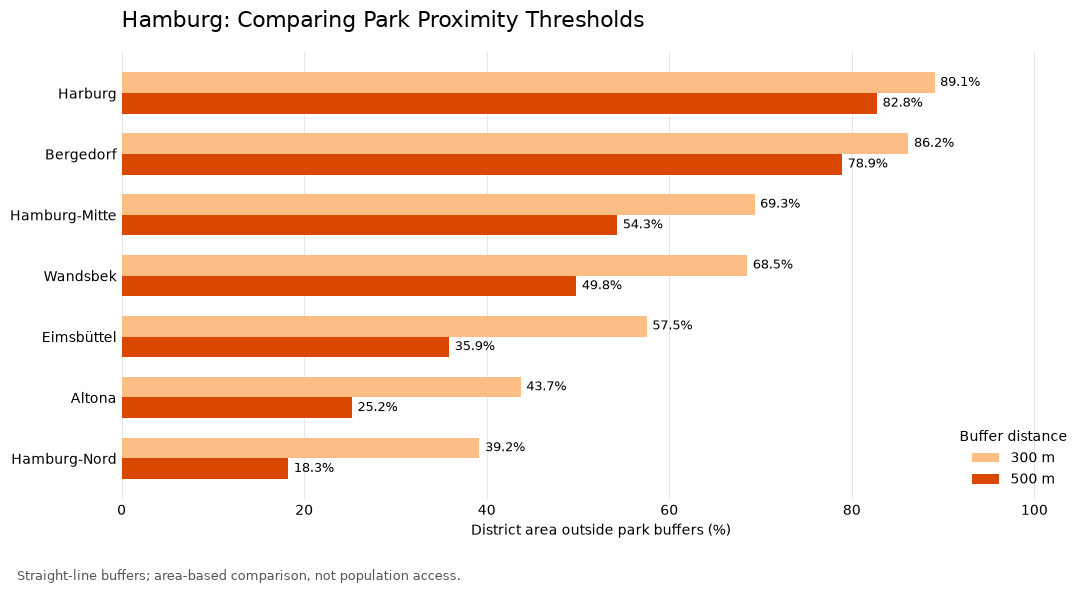

Comparison chart and CSV saved to: C:\Users\PC\Documents\hamburg-green-space\outputs


In [9]:
# Order districts by their 500 m result.
plot_data = comparison.sort_values(
    "outside_500m_pct", ascending=False
).reset_index(drop=True)

y = np.arange(len(plot_data))
height = 0.34

fig, ax = plt.subplots(figsize=(11, 6))

bars_300 = ax.barh(
    y - height / 2,
    plot_data["outside_300m_pct"],
    height=height,
    color="#FDBE85",
    label="300 m"
)

bars_500 = ax.barh(
    y + height / 2,
    plot_data["outside_500m_pct"],
    height=height,
    color="#D94701",
    label="500 m"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_data["bezirk_name"])
ax.invert_yaxis()
ax.set_xlim(0, 105)
ax.set_xticks(np.arange(0, 101, 20))

ax.bar_label(bars_300, fmt="%.1f%%", padding=4, fontsize=9)
ax.bar_label(bars_500, fmt="%.1f%%", padding=4, fontsize=9)

ax.set_title(
    "Hamburg: Comparing Park Proximity Thresholds",
    loc="left", fontsize=16, pad=18
)
ax.set_xlabel("District area outside park buffers (%)")
ax.legend(title="Buffer distance", frameon=False, loc="lower right")

ax.set_axisbelow(True)
ax.grid(axis="x", color="#E5E5E5", linewidth=0.7)
ax.tick_params(axis="both", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.text(
    0.02, 0.025,
    "Straight-line buffers; area-based comparison, not population access.",
    fontsize=9, color="#555555"
)
fig.tight_layout(rect=[0, 0.07, 1, 1])

# Export the chart and the comparison table.
OUTPUTS.mkdir(parents=True, exist_ok=True)

for extension in ("png", "pdf"):
    fig.savefig(
        OUTPUTS / f"district_park_proximity_300m_vs_500m.{extension}",
        dpi=300,
        bbox_inches="tight"
    )

plot_data.to_csv(
    OUTPUTS / "district_park_proximity_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

plt.show()
print("Comparison chart and CSV saved to:", OUTPUTS)

In [10]:
import shutil

free_gb = shutil.disk_usage(ROOT).free / (1024 ** 3)
print(f"Free disk space: {free_gb:.1f} GB")

Free disk space: 697.6 GB
